# Signal Processing with Audio

notebook tested with python 3.12. Since it has few dependencies any recent python version should work.

We will use numpy to:
- Load and play a waveform
- Compute an FFT spectrum
- Apply low-pass, high-pass, and band-pass filters
- See how convolution kernels look in the time and frequency domain
- Separate two mixed "instruments" using a frequency-domain mask

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from IPython.display import Audio, display


rng = np.random.default_rng(0)

SR = 22050  # sample rate

## Audio signals and the FFT

### Synthesise a musical chord

We build an **A minor chord** from three pure sine waves at 220 Hz, 261 Hz, and 330 Hz,
plus a little broadband noise to make the spectrum more interesting.

In [5]:
duration = 2.0
t = np.arange(int(SR * duration)) / SR

note_freqs = {"A3": 220.0, "C4": 261.63, "E4": 329.63}
chord = sum(np.sin(2 * np.pi * f * t) for f in note_freqs.values())
chord += 0.15 * rng.standard_normal(chord.shape)  # background noise
chord /= np.abs(chord).max()

print(f"Signal: {len(chord)} samples, {duration}s at {SR} Hz")
display(Audio(chord, rate=SR))

chord: 44100
Signal: 44100 samples, 2.0s at 22050 Hz


### Visualise the waveform

Plotting the raw waveform shows the time structure but hides the frequency content.
The three frequencies 'beat' against each other, creating the amplitude modulation visible here.

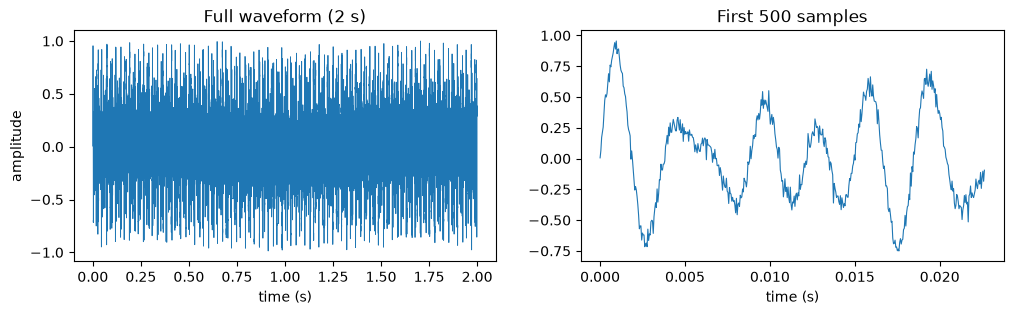

In [3]:
def plot_waveform(t, wave):
    _, axes = plt.subplots(1, 2, figsize=(12, 3))

    axes[0].plot(t, wave, lw=0.6)
    axes[0].set_xlabel("time (s)")
    axes[0].set_ylabel("amplitude")
    axes[0].set_title("Full waveform (2 s)")

    axes[1].plot(t[:500], wave[:500], lw=0.8)
    axes[1].set_xlabel("time (s)")
    axes[1].set_title("First 500 samples")


plot_waveform(t, chord)

### Computing the FFT

- `np.fft.rfft(x)`: FFT for real-valued input, returns only the non-redundant half (DC to Nyquist)
- `np.fft.rfftfreq(n, d=1/SR)`: frequency axis in Hz for an `n`-sample signal sampled at `SR` Hz. We use for plots.
- `np.abs(X)`: magnitude spectrum
- `np.angle(X)`: phase spectrum

**Nyquist limit**: with our default sampling rate SR=22050 we can only represent frequencies up to SR/2 = 11 025 Hz.

In [4]:
X = np.fft.rfft(chord)  # complex spectrum
freqs = np.fft.rfftfreq(len(chord), d=1 / SR)  # Hz axis
magnitude = np.abs(X)

print(f"Input length: {len(chord)},  rfft output length: {len(X)}")
print(
    f"Frequency resolution: {freqs[1]:.4f} Hz/bin"
)  # this is the resolution of the fft
print(f"Maximum representable frequency: {freqs[-1]:.1f} Hz")

Input length: 44100,  rfft output length: 22051
Frequency resolution: 0.5000 Hz/bin
Maximum representable frequency: 11025.0 Hz


### Spectrum in linear and log scale

The three chord notes stand out as sharp peaks. The log scale reveals the noise floor and makes it easier to compare peaks that differ by orders of magnitude. Most plots (also for images) will be in log scale.

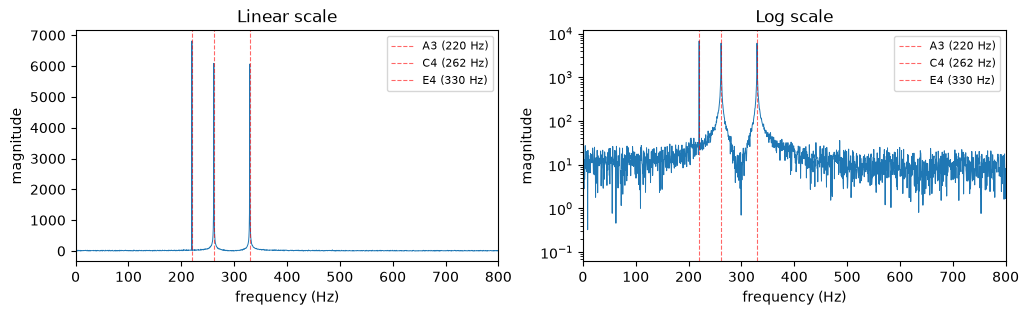

In [5]:
def plot_freq(wave):
    X = np.fft.rfft(wave)  # complex spectrum
    freqs = np.fft.rfftfreq(len(wave), d=1 / SR)  # Hz axis
    magnitude = np.abs(X)

    _, axes = plt.subplots(1, 2, figsize=(12, 3))
    for ax, yscale, title in zip(
        axes, ["linear", "log"], ["Linear scale", "Log scale"]
    ):
        ax.plot(freqs, magnitude, lw=0.7)
        ax.set_yscale(yscale)
        ax.set_xlim(0, 800)
        ax.set_xlabel("frequency (Hz)")
        ax.set_ylabel("magnitude")
        ax.set_title(title)
        for name, f in note_freqs.items():
            ax.axvline(
                f, color="r", lw=0.8, ls="--", alpha=0.6, label=f"{name} ({f:.0f} Hz)"
            )
        ax.legend(fontsize=8)


plot_freq(chord)

### Frequency-domain filtering

We can implement a simple frequency-domain filter in three steps:
1. `rfft` to get the complex spectrum
2. multiply the spectrum by a real-valued mask to suppress frequencies
3. `irfft` to convert the filtered signal back in time domain

Notice that many actual audio applications (especially real-time) don't do this explicit fft -> filter -> ifft process, due to several issues such as real-time constraints or sampling limitations.

In [6]:
def freq_filter(x, sr, mask_fn):
    """Apply a frequency-domain mask defined by mask_fn(freqs_hz)."""
    X = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1 / sr)
    return np.fft.irfft(X * mask_fn(f), n=len(x))

### Low-pass filter

Cutting everything above ~240 Hz leaves only the lowest note (A3 at 220 Hz).
This is what speech sounds like through a thick wall. A kind of muffled voice / underwater effect.

Low-pass at 240 Hz. Only the root A3 note survives:


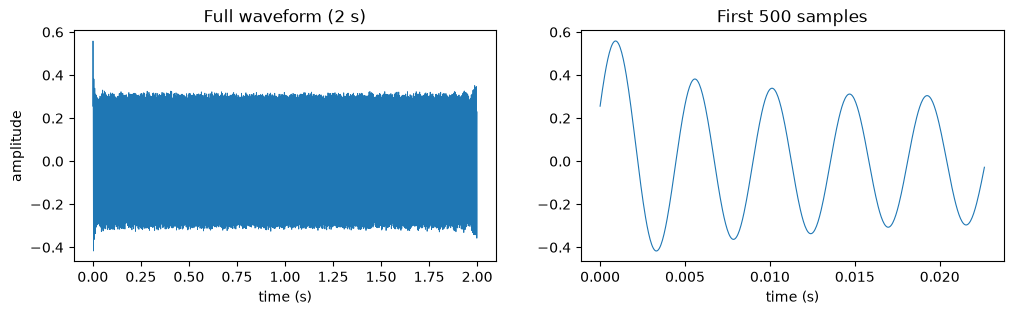

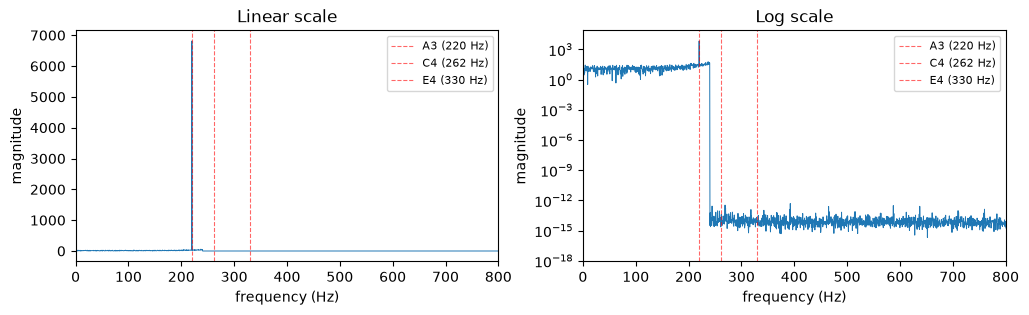

In [7]:
lp_cutoff = 240  # Hz
chord_lp = freq_filter(chord, SR, lambda f: (f <= lp_cutoff).astype(float))

plot_waveform(t, chord_lp)
plot_freq(chord_lp)

print(f"Low-pass at {lp_cutoff} Hz. Only the root A3 note survives:")
display(Audio(chord_lp, rate=SR))

### High-pass filter

Cutting everything below 300 Hz removes the bass and leaves the upper harmonics and noise.
Classic telephone bandwidth is roughly 300–3400 Hz.

High-pass at 300 Hz. Bass is gone, upper notes and noise remain:


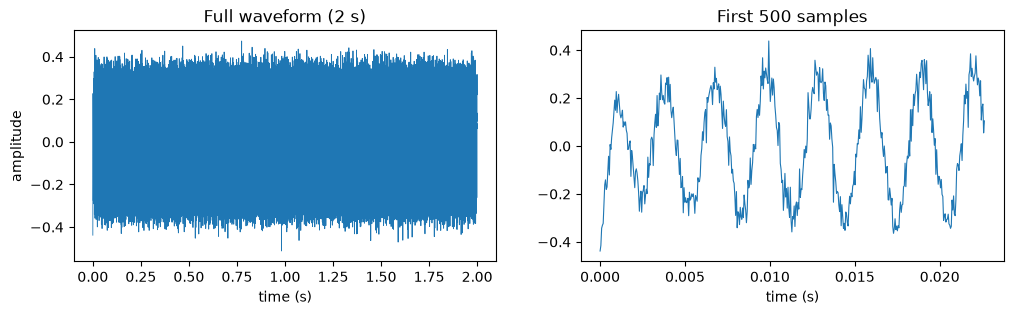

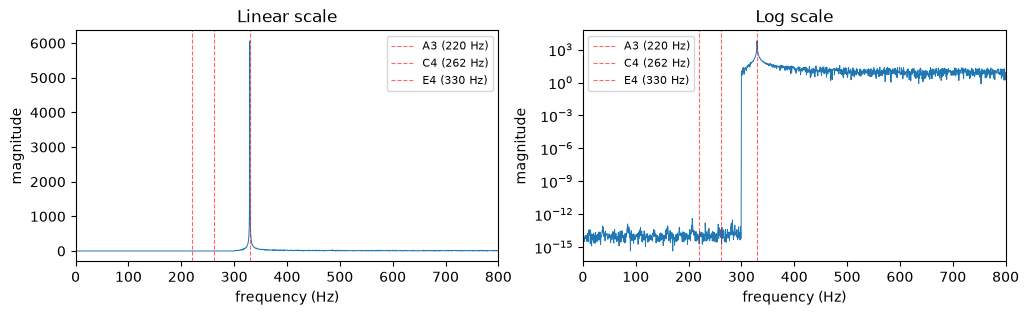

In [8]:
hp_cutoff = 300  # Hz
chord_hp = freq_filter(chord, SR, lambda f: (f >= hp_cutoff).astype(float))

plot_waveform(t, chord_hp)
plot_freq(chord_hp)

print(f"High-pass at {hp_cutoff} Hz. Bass is gone, upper notes and noise remain:")
display(Audio(chord_hp, rate=SR))

### Band-pass filte

A narrow band-pass around 261 Hz picks out only the C4 note from the chord.

Band-pass 245–280 Hz. Isolates C4 (261.6 Hz):


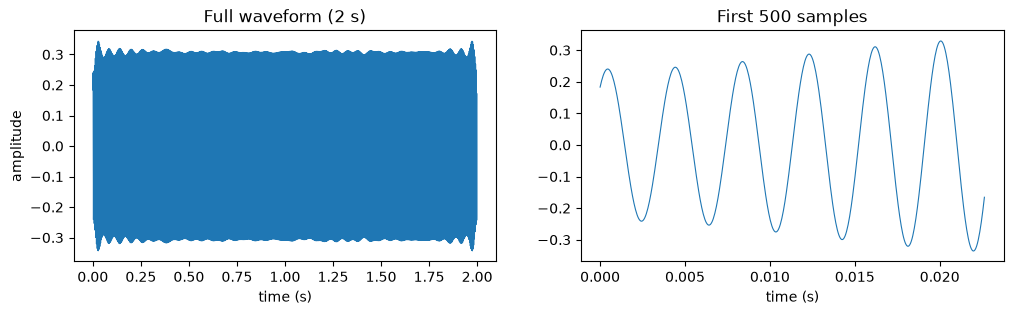

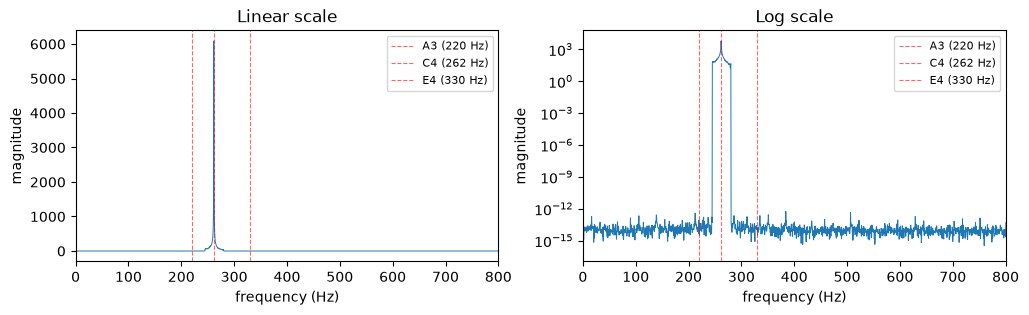

In [9]:
bp_lo, bp_hi = 245, 280  # Hz
chord_bp = freq_filter(chord, SR, lambda f: ((f >= bp_lo) & (f <= bp_hi)).astype(float))

plot_waveform(t, chord_bp)
plot_freq(chord_bp)

print(f"Band-pass {bp_lo}–{bp_hi} Hz. Isolates C4 ({note_freqs['C4']:.1f} Hz):")
display(Audio(chord_bp, rate=SR))

### Separating two mixed signals

In music, every instrument usually occupies a specific range of frequencies (at least in a well-mixed album). As a consequence, we can separate instruments by playing with equalization, that is by designing a proper band-pass filter. The separation is not perfect of course.

In [10]:
melody_freqs = {"D5": 587.33, "E5": 659.25}
melody = sum(np.sin(2 * np.pi * f * t) for f in melody_freqs.values())
melody /= np.abs(melody).max()

mix = 0.5 * chord + 0.5 * melody
mix /= np.abs(mix).max()

print("Mixed signal (chord + melody):")
display(Audio(mix, rate=SR))

# Separate using band-pass filters
recovered_chord = freq_filter(mix, SR, lambda f: (f <= 400).astype(float))
recovered_melody = freq_filter(mix, SR, lambda f: (f >= 500).astype(float))

print("Recovered chord (low-pass ≤ 400 Hz):")
display(Audio(recovered_chord, rate=SR))
print("Recovered melody (high-pass ≥ 500 Hz):")
display(Audio(recovered_melody, rate=SR))

Mixed signal (chord + melody):


Recovered chord (low-pass ≤ 400 Hz):


Recovered melody (high-pass ≥ 500 Hz):


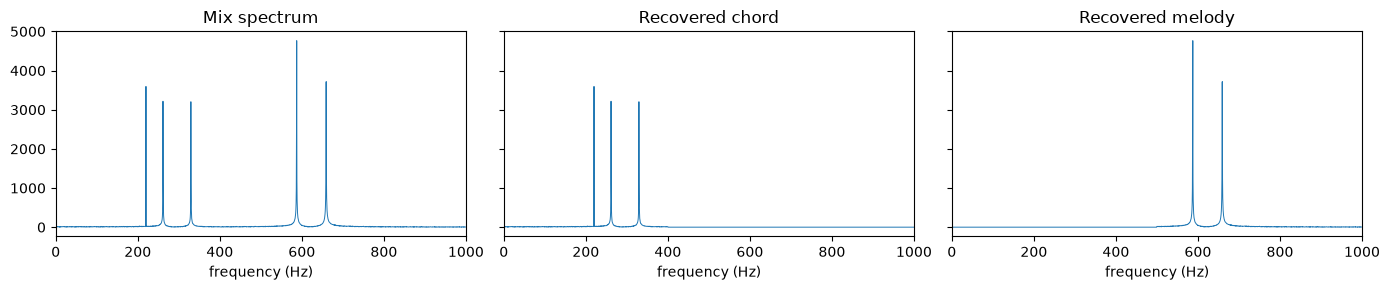

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)
for ax, sig, title in zip(
    axes,
    [mix, recovered_chord, recovered_melody],
    ["Mix spectrum", "Recovered chord", "Recovered melody"],
):
    M = np.abs(np.fft.rfft(sig))
    F = np.fft.rfftfreq(len(sig), d=1 / SR)
    ax.plot(F, M, lw=0.7)
    ax.set_xlim(0, 1000)
    ax.set_xlabel("frequency (Hz)")
    ax.set_title(title)
plt.tight_layout()
plt.show()

## 1D Convolution

`np.convolve` is the numpy convolution operator.
Similar to CNN convolutions, `np.convolve` has several padding modes. Be aware of them because they change the size of the output (and shift it).

```
np.convolve(x, h, mode='full')   # length len(x)+len(h)-1
np.convolve(x, h, mode='same')   # length len(x), centred
np.convolve(x, h, mode='valid')  # length len(x)-len(h)+1, no boundary effects
```

For most filtering tasks `mode='same'` is convenient because the output has the same length as the input.

In [12]:
x = np.zeros(60)
x[20:40] = 1.0  # rectangular pulse
x += 0.1 * rng.standard_normal(x.shape)  # add a little noise

h = np.ones(7)  # a box kernel
for mode in ["full", "same", "valid"]:
    print(f"mode='{mode}':  output shape = {np.convolve(x, h, mode=mode).shape}")

mode='full':  output shape = (66,)
mode='same':  output shape = (60,)
mode='valid':  output shape = (54,)


Text(0.5, 1.0, 'Rectangle + noise signal')

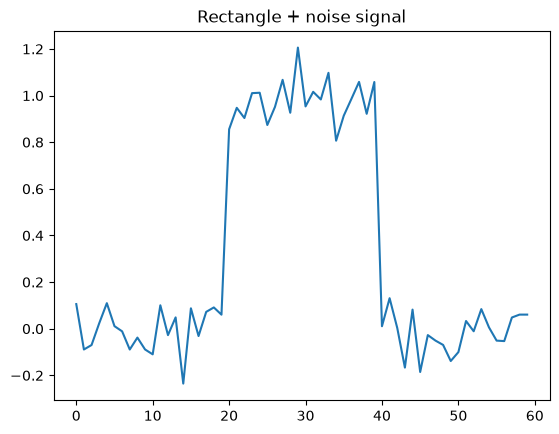

In [13]:
plt.plot(x)
plt.title("Rectangle + noise signal")

### Three fundamental kernels

| Kernel | Effect in time domain | Effect in frequency domain |
|---|---|---|
| Box (uniform average) | Smoothing (removes sharp edges) | Low-pass (but with strong ringing sidelobes) |
| Gaussian | Smooth blurring (preserves shape) | Low-pass (clean, no ringing) |
| Derivative `[-1, 0, 1]` | Detects transitions / edges | High-pass (amplifies high frequencies) |


We will discuss more in detail these kernels in the next lecture. Right now, we just look at them with an example.

In [14]:
box = np.ones(7) / 7

gauss_win = signal.windows.gaussian(15, std=2.5)
gauss = gauss_win / gauss_win.sum()

deriv = np.array([-1, 0, 1]) / 2.0

x_box = np.convolve(x, box, mode="same")
x_gauss = np.convolve(x, gauss, mode="same")
x_deriv = np.convolve(x, deriv, mode="same")

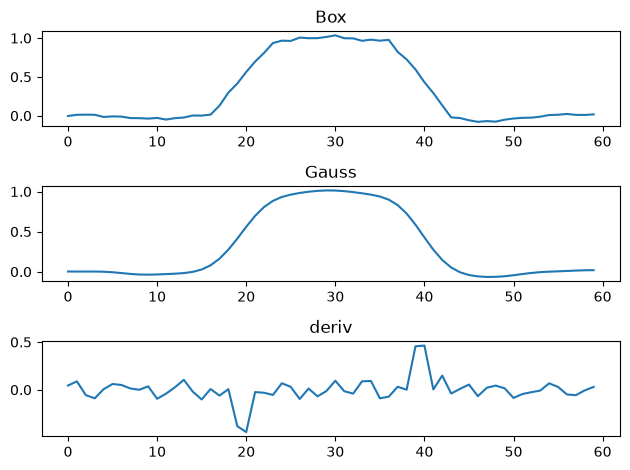

In [15]:
plt.subplot(3, 1, 1)
plt.title("Box")
plt.plot(x_box)

plt.subplot(3, 1, 2)
plt.title("Gauss")
plt.plot(x_gauss)

plt.subplot(3, 1, 3)
plt.title("deriv")
plt.plot(x_deriv)

plt.tight_layout()

### Results in the time domain

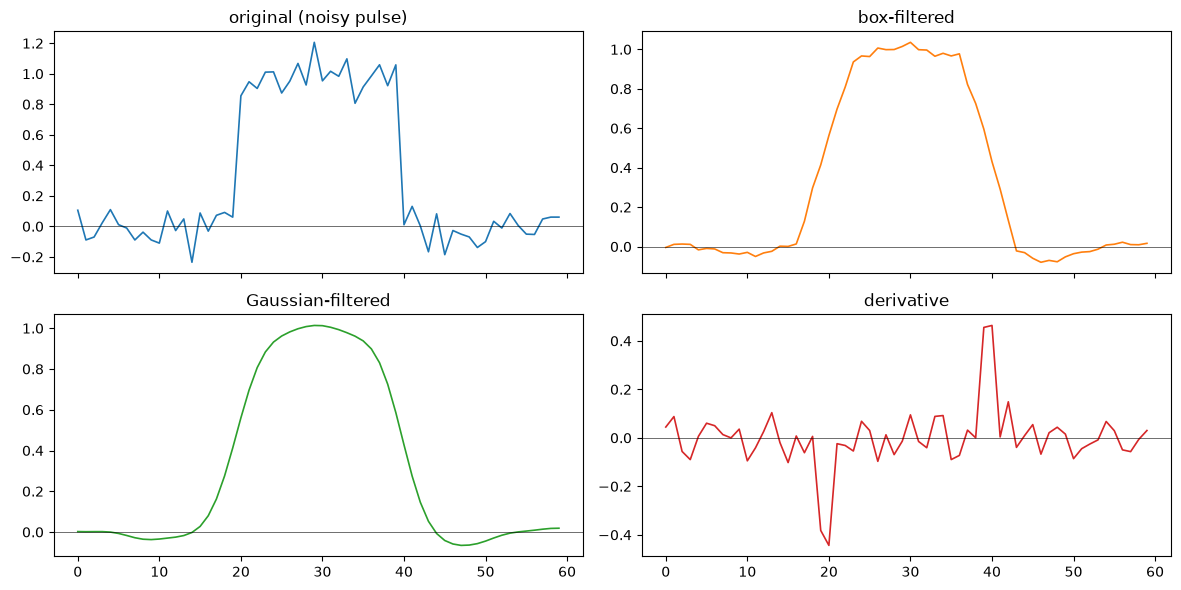

In [16]:
idx = np.arange(len(x))
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
for ax, sig, title, color in zip(
    axes.ravel(),
    [x, x_box, x_gauss, x_deriv],
    ["original (noisy pulse)", "box-filtered", "Gaussian-filtered", "derivative"],
    ["C0", "C1", "C2", "C3"],
):
    ax.plot(idx, sig, color=color, lw=1.2)
    ax.set_title(title)
    ax.axhline(0, color="k", lw=0.4)
plt.tight_layout()
plt.show()

### Kernels in the frequency domain

Taking the FFT of a kernel reveals why it behaves the way it does. During the previous lecture, we have seen that the convolution theorem says that convolution in the time domain = multiplication in the frequency domain: $\mathcal{F}\{x * h\} = \mathcal{F}\{x\} \cdot \mathcal{F}\{h\}$

The kernel's FFT is its **frequency response**: which frequencies does it keep or kill?

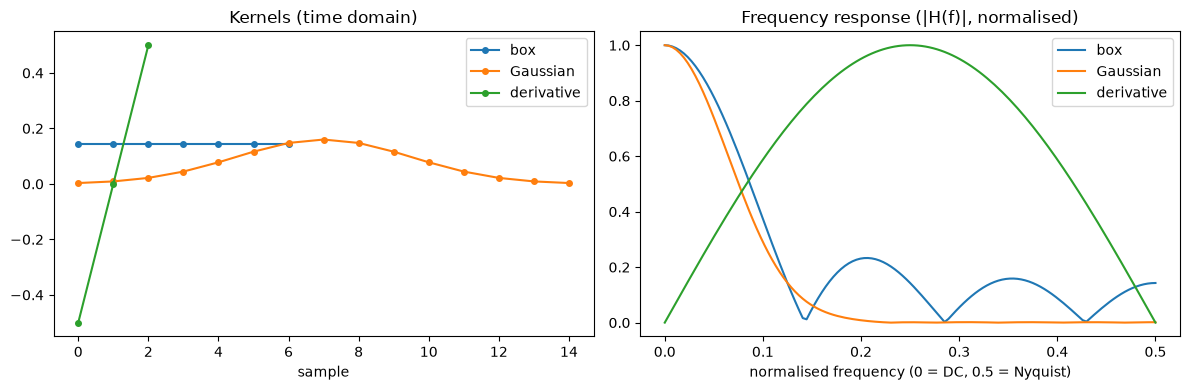

In [17]:
N = 256  # zero-pad kernels to this length for a smooth frequency-response curve
bins = np.fft.rfftfreq(N)  # normalised frequency 0..0.5

kernels = {"box": box, "Gaussian": gauss, "derivative": deriv}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time-domain view of each kernel
for name, k in kernels.items():
    kpad = np.zeros(N)
    kpad[: len(k)] = k
    axes[0].plot(k, "o-", ms=4, label=name)
axes[0].set_title("Kernels (time domain)")
axes[0].set_xlabel("sample")
axes[0].legend()

# Frequency-response view of each kernel
for name, k in kernels.items():
    kpad = np.zeros(N)
    kpad[: len(k)] = k
    H = np.abs(np.fft.rfft(kpad))
    axes[1].plot(bins, H / H.max(), label=name)
axes[1].set_title("Frequency response (|H(f)|, normalised)")
axes[1].set_xlabel("normalised frequency (0 = DC, 0.5 = Nyquist)")
axes[1].legend()

plt.tight_layout()
plt.show()

- **Box**: low-pass (suppresses high frequencies), but the frequency response has strong
  sidelobes. In the time domain these appear as **ringing artefacts** at sharp transitions. We will see these artifact also in images.
- **Gaussian**: also low-pass, but the frequency response is a smooth bell shape (a Gaussian's Fourier transform is a Gaussian). The standard smooth blurring due to no ringing.
- **Derivative** `[-1, 0, 1]`: near-zero response at DC, growing towards the Nyquist (**high-pass** filter). It amplifies noise (which lives at high frequencies) and highlights edges (i.e. sharp transitions).

## Wrap-up

numpy API:

- FFT of real signal: `np.fft.rfft(x)` / `np.fft.irfft(X, n=len(x))`
- Frequency axis: `np.fft.rfftfreq(n, d=1/SR)`
- Convolution: `np.convolve(x, h, mode='same')`
- Gaussian window: `scipy.signal.windows.gaussian(M, std=s)`
- Play audio: `IPython.display.Audio(array, rate=SR)`


# Exercises

- try to construct different signals (or use existing samples) and plot their FFT. What are the dominant frequencies? if the signals contains multiple sources, can you separate it?
- try to hand-design filters for your own signal (e.g. clean a noisy recording of a voice)
  - you can find samples here: https://samplefocus.com/tag/talking